# Diabetes Risk Screening - End-to-End Notebook

This notebook builds and evaluates a diabetes risk prediction system and exports deployment-ready artifacts for Streamlit.

Target: binary classification (`Outcome` = 1 at risk, 0 not at risk).

## 1. Environment and Runtime Configuration (VS Code + .venv)
Configure deterministic behavior and cache paths for restricted environments.

In [1]:
import json
import os
import platform
import random
import sys
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Keep matplotlib/font caches writable in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / ".cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Matplotlib is building the font cache; this may take a moment.


Python: 3.9.6
Platform: macOS-26.5.1-arm64-arm-64bit
pandas: 2.3.3
numpy: 2.0.2
scikit-learn: 1.6.1


## 2. Robust Data Loading (Local File First, URL Fallback)
Load local dataset first, then fallback to URL only when needed with explicit error logs.

In [2]:
FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET = "Outcome"
ALL_COLUMNS = FEATURES + [TARGET]
DATASET_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
DATASET_PATH = Path("dataset.csv")
FIGURES_DIR = Path("report_assets/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def robust_load_dataset(local_path: Path, remote_url: str) -> pd.DataFrame:
    if local_path.exists():
        print(f"Loading local dataset from: {local_path}")
        df_local = pd.read_csv(local_path)
        if TARGET not in df_local.columns and df_local.shape[1] == len(ALL_COLUMNS):
            df_local.columns = ALL_COLUMNS
        return df_local

    print("Local dataset not found. Attempting remote download...")
    try:
        df_remote = pd.read_csv(remote_url, header=None)
        df_remote.columns = ALL_COLUMNS
        df_remote.to_csv(local_path, index=False)
        print(f"Downloaded and saved dataset to: {local_path}")
        return df_remote
    except Exception as exc:
        print("Remote load failed. Common reason: proxy/tunnel restriction (for example HTTP 403).")
        raise RuntimeError("Dataset unavailable locally and remote download failed.") from exc


df = robust_load_dataset(DATASET_PATH, DATASET_URL)
print("Dataset shape:", df.shape)
df.head()

Loading local dataset from: dataset.csv
Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Dataset Schema, Type Casting, and Validation Checks
Enforce schema consistency and fail early on drift.

In [3]:
# Force expected schema
if list(df.columns) != ALL_COLUMNS:
    if df.shape[1] == len(ALL_COLUMNS):
        df.columns = ALL_COLUMNS
    else:
        raise ValueError(f"Unexpected schema: expected {len(ALL_COLUMNS)} columns, got {df.shape[1]}")

for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").astype("Int64")

assert set(df[TARGET].dropna().unique()).issubset({0, 1}), "Target labels must be 0/1"
assert df["Age"].dropna().between(10, 120).all(), "Age out of expected range"

print("Missing values before cleaning:")
print(df.isna().sum())
print("\nClass distribution:")
print(df[TARGET].value_counts(dropna=False))

Missing values before cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: Int64


## 4. Exploratory Analysis and Target Distribution

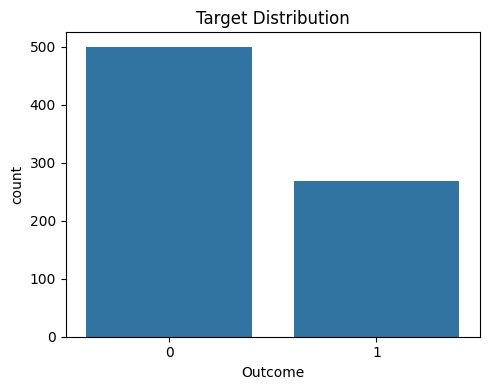

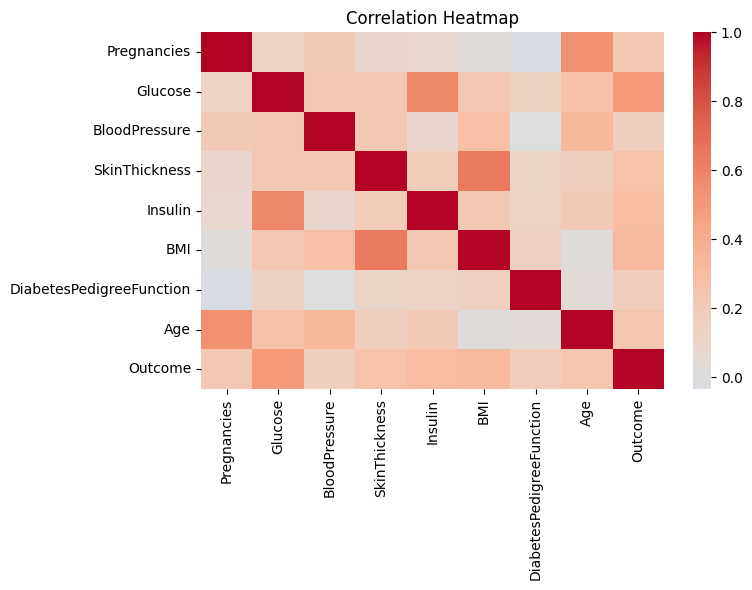

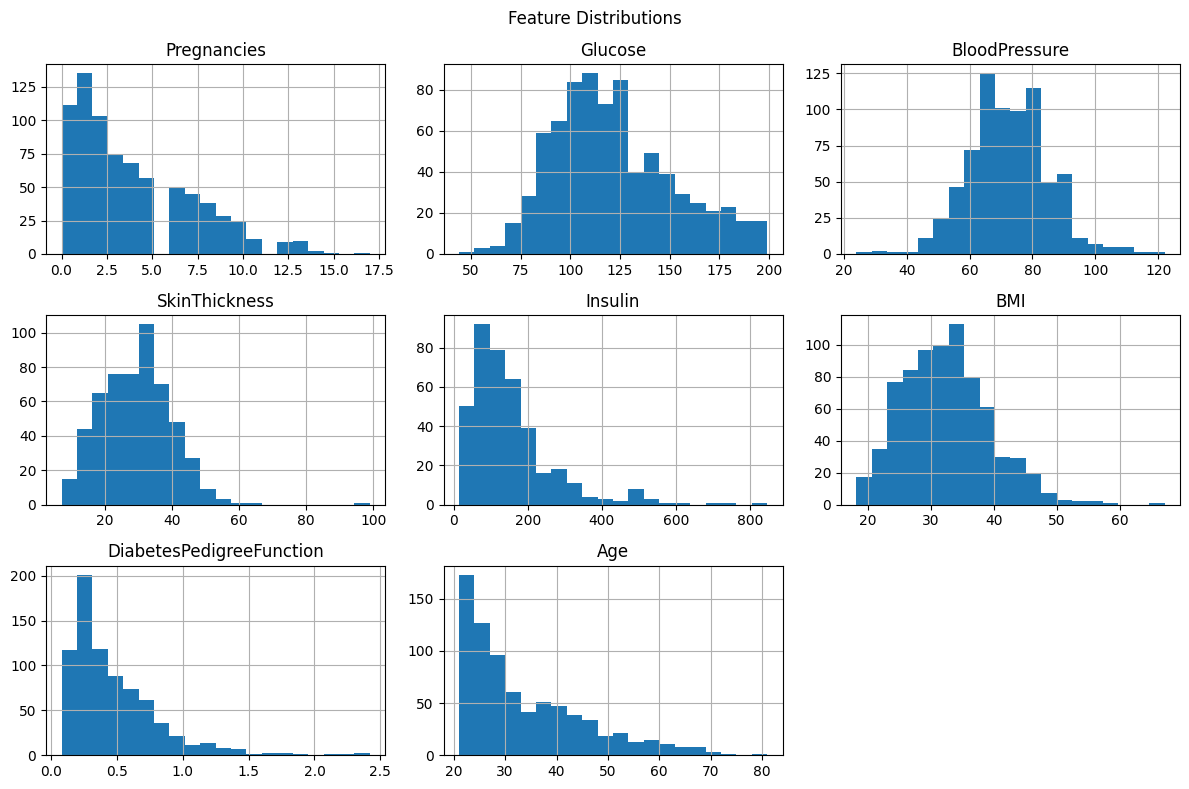

In [4]:
INVALID_ZERO_COLUMNS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
clean_df = df.copy().drop_duplicates()
for col in INVALID_ZERO_COLUMNS:
    clean_df[col] = clean_df[col].replace(0, np.nan)

plt.figure(figsize=(5, 4))
sns.countplot(x=TARGET, data=clean_df)
plt.title("Target Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_target_distribution.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(clean_df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_correlation_heatmap.png", dpi=220)
plt.show()

clean_df[FEATURES].hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_feature_distributions.png", dpi=220)
plt.show()

## 5. Preprocessing Pipeline (Imputation, Encoding, Scaling)
## 6. Train/Validation/Test Split with Reproducibility

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

x = clean_df[FEATURES]
y = clean_df[TARGET].astype(int)

x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, random_state=SEED, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print("Train/Validation/Test sizes:", len(x_train), len(x_val), len(x_test))
print("Class ratio train:", y_train.mean().round(3), "val:", y_val.mean().round(3), "test:", y_test.mean().round(3))

numeric_pipe = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
preprocessor = ColumnTransformer(transformers=[("num", numeric_pipe, FEATURES)])

Train/Validation/Test sizes: 460 154 154
Class ratio train: 0.348 val: 0.351 test: 0.351


## 7. Baseline and Candidate Model Training
## 8. Cross-Validation and Metric Comparison

In [6]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=2, class_weight="balanced", random_state=SEED
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEED),
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows = []
fitted_pipelines = {}
start = time.time()
for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", estimator)])
    cv_scores = cross_validate(pipe, x_train, y_train, cv=cv, scoring=scoring)
    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)
    y_prob = pipe.predict_proba(x_test)[:, 1]

    rows.append(
        {
            "model": name,
            "cv_accuracy": cv_scores["test_accuracy"].mean(),
            "cv_precision": cv_scores["test_precision"].mean(),
            "cv_recall": cv_scores["test_recall"].mean(),
            "cv_f1": cv_scores["test_f1"].mean(),
            "cv_roc_auc": cv_scores["test_roc_auc"].mean(),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision": precision_score(y_test, y_pred),
            "test_recall": recall_score(y_test, y_pred),
            "test_f1": f1_score(y_test, y_pred),
            "test_roc_auc": roc_auc_score(y_test, y_prob),
            "train_seconds": cv_scores["fit_time"].mean(),
        }
    )
    fitted_pipelines[name] = pipe

elapsed = time.time() - start
metrics_df = pd.DataFrame(rows).sort_values(["test_recall", "test_f1", "test_roc_auc"], ascending=False)
metrics_df

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,train_seconds
1,Random Forest,0.763043,0.652932,0.68125,0.664431,0.818958,0.746753,0.627119,0.685185,0.654867,0.829259,0.317493
0,Logistic Regression,0.758696,0.642572,0.70000,0.666868,0.832188,0.727273,0.596774,0.685185,0.637931,0.815556,0.015635
2,Gradient Boosting,0.760870,0.705767,0.56875,0.622711,0.802187,0.714286,0.613636,0.500000,0.551020,0.807963,0.233062


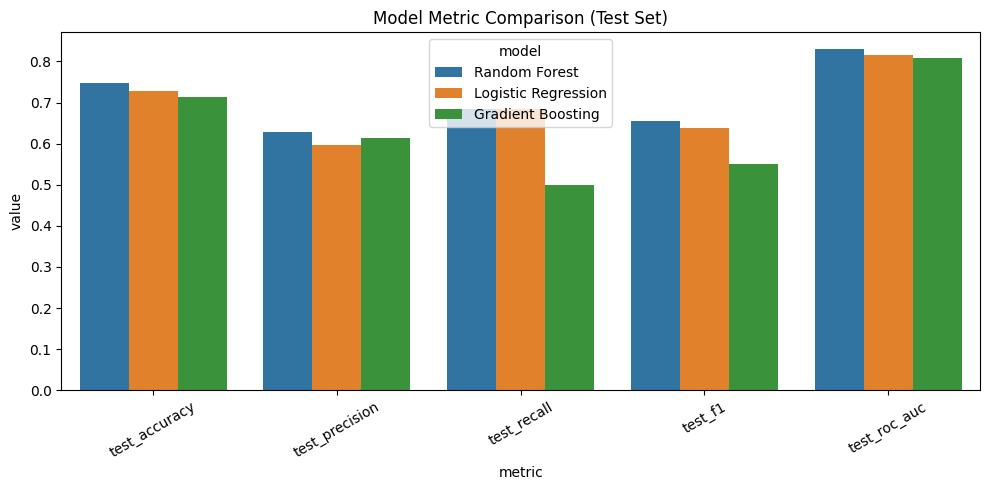

Training and CV completed in 3.89 seconds


In [7]:
plt.figure(figsize=(10, 5))
plot_df = metrics_df[["model", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]].melt(
    id_vars="model", var_name="metric", value_name="value"
)
sns.barplot(data=plot_df, x="metric", y="value", hue="model")
plt.xticks(rotation=30)
plt.title("Model Metric Comparison (Test Set)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_metric_comparison.png", dpi=220)
plt.show()

metrics_df.to_csv("model_metrics.csv", index=False)
print("Training and CV completed in", round(elapsed, 2), "seconds")

## 9. Error Analysis (Confusion Matrix, ROC, Threshold Tuning)
## 10. Model Selection, Serialization, and Inference Helper

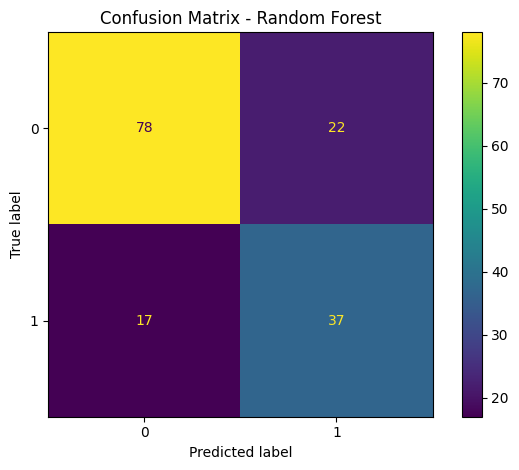

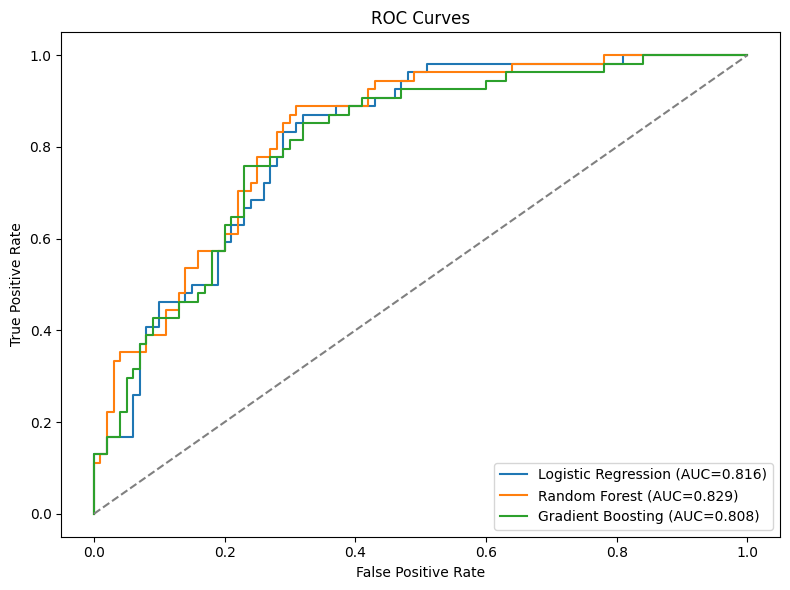

,threshold,precision,recall,f1
0,0.30,0.539326,0.888889,0.671329
1,0.35,0.607595,0.888889,0.721805
2,0.40,0.605263,0.851852,0.707692
3,0.45,0.615385,0.740741,0.672269
4,0.50,0.627119,0.685185,0.654867
5,0.55,0.632653,0.574074,0.601942
6,0.60,0.659091,0.537037,0.591837
7,0.65,0.648649,0.444444,0.527473
8,0.70,0.677419,0.388889,0.494118


In [8]:
best_name = metrics_df.iloc[0]["model"]
best_model = fitted_pipelines[best_name]

ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test)
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 6))
for name, pipe in fitted_pipelines.items():
    probs = pipe.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_comparison.png", dpi=220)
plt.show()

# Threshold tuning for recall-oriented screening.
probs = best_model.predict_proba(x_test)[:, 1]
threshold_grid = np.arange(0.30, 0.71, 0.05)
threshold_rows = []
for t in threshold_grid:
    pred_t = (probs >= t).astype(int)
    threshold_rows.append(
        {
            "threshold": round(float(t), 2),
            "precision": precision_score(y_test, pred_t),
            "recall": recall_score(y_test, pred_t),
            "f1": f1_score(y_test, pred_t),
        }
    )
threshold_df = pd.DataFrame(threshold_rows)
threshold_df

In [ ]:
import pickle

bundle = {
    "model": best_model,
    "features": FEATURES,
    "model_name": best_name,
    "selected_threshold": 0.50,
}
with open("model.pkl", "wb") as f:
    pickle.dump(bundle, f)
print("Selected model:", best_name)
print("Saved: model.pkl")


def _validate_input_frame(df_in: pd.DataFrame) -> pd.DataFrame:
    missing = [c for c in FEATURES if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df_in[FEATURES].copy()


def predict_batch(input_df: pd.DataFrame, threshold: float = 0.50) -> pd.DataFrame:
    x_in = _validate_input_frame(input_df)
    p1 = best_model.predict_proba(x_in)[:, 1]
    y_hat = (p1 >= threshold).astype(int)
    return pd.DataFrame({"prediction": y_hat, "probability": p1})


def predict_single(input_dict: dict, threshold: float = 0.50) -> dict:
    row_df = pd.DataFrame([input_dict])
    out = predict_batch(row_df, threshold=threshold).iloc[0]
    return {"prediction": int(out["prediction"]), "probability": float(out["probability"])}

Selected model: Random Forest
Saved: model.pkl


## 11. Streamlit-Ready Prediction Function and Artifact Contract
Provide stable functions for app integration: load_model, predict_proba, predict_label.

In [11]:
def load_model(path: str = "model.pkl"):
    return joblib.load(path)


def predict_proba(input_df: pd.DataFrame, bundle_obj: dict) -> np.ndarray:
    x_in = _validate_input_frame(input_df)
    return bundle_obj["model"].predict_proba(x_in)[:, 1]


def predict_label(input_df: pd.DataFrame, bundle_obj: dict, threshold: float = 0.50) -> np.ndarray:
    probs = predict_proba(input_df, bundle_obj)
    return (probs >= threshold).astype(int)


sample_input = {
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 20,
    "Insulin": 79,
    "BMI": 32.0,
    "DiabetesPedigreeFunction": 0.47,
    "Age": 33,
}

bundle_check = load_model("model.pkl")
sample_df = pd.DataFrame([sample_input])
print("Smoke test probability:", float(predict_proba(sample_df, bundle_check)[0]))
print("Smoke test label:", int(predict_label(sample_df, bundle_check)[0]))

Smoke test probability: 0.3020784655099721
Smoke test label: 0


## 12. Reproducible Run Logs and Debug Utilities

In [12]:
RUN_DIR = Path("run_logs")
RUN_DIR.mkdir(exist_ok=True)
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

run_meta = {
    "timestamp": stamp,
    "seed": SEED,
    "python": sys.version,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "best_model": best_name,
    "selected_threshold": 0.50,
    "elapsed_seconds": round(elapsed, 3),
}

(Path(RUN_DIR) / f"run_meta_{stamp}.json").write_text(json.dumps(run_meta, indent=2), encoding="utf-8")
metrics_df.to_csv(Path(RUN_DIR) / f"metrics_{stamp}.csv", index=False)
threshold_df.to_csv(Path(RUN_DIR) / f"thresholds_{stamp}.csv", index=False)

print("Saved run logs to:", RUN_DIR)
print(run_meta)

Saved run logs to: run_logs
{'timestamp': '20260712_230729', 'seed': 42, 'python': '3.9.6 (default, May 22 2026, 11:13:45) \n[Clang 21.0.0 (clang-2100.1.1.101)]', 'pandas': '2.3.3', 'numpy': '2.0.2', 'best_model': 'Random Forest', 'selected_threshold': 0.5, 'elapsed_seconds': 3.887}
